In [9]:
import numpy as np
from scipy.linalg import tanhm
import matplotlib.pyplot as plt
import itertools

In [10]:
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def krons(ops):
    res = ops[0]
    for op in ops[1:]:
        res = np.kron(res, op)
    return res

def to_density(vec):
    return np.outer(vec, vec.conj())

def generate_paulis(n, model="quantum"):
    """
    Generates Pauli strings for an n-qubit system.
    Includes nearest neightbor ZZ interactions, 1-body field terms, and Identity.
    """
    paulis = []
    
    # ZZ Interactions 
    for i in range(n-1):
        ops = [I] * n
        ops[i] = Z
        ops[i+1] = Z
        paulis.append(krons(ops))
            
    # 1-body Interactions
    for i in range(n):
        ops = [I] * n
        if model == "quantum":
            ops[i] = X
        elif model == "classical":
            ops[i] = Z
        paulis.append(krons(ops))
        
    # Identity term
    paulis.append(krons([I] * n))
    
    return paulis

def make_training_states(n):
    states = []
    dim = 2**n
    k0, k1 = np.array([1, 0]), np.array([0, 1])
    kp, km = np.array([1, 1])/np.sqrt(2), np.array([1, -1])/np.sqrt(2)

    # Computational basis states
    for bits in itertools.product([k0, k1], repeat=n):
        states.append(to_density(krons(bits)))
    
    # +/- basis states
    for bits in itertools.product([kp, km], repeat=n):
        states.append(to_density(krons(bits)))

    # GHZ state: (|00...0> + |11...1>) / sqrt(2)
    ghz_0 = krons([k0] * n)
    ghz_1 = krons([k1] * n)
    ghz = (ghz_0 + ghz_1) / np.sqrt(2)
    states.append(to_density(ghz))
    
    # Maximally mixed state
    states.append(np.eye(dim, dtype=complex) / dim)
    
    # Random mixed states
    for _ in range(3):
        A = np.random.randn(dim, dim) + 1j * np.random.randn(dim, dim)
        rho = A @ A.conj().T
        states.append(rho / np.trace(rho))

    return np.array(states)

def fdd_tanh_matrix(eigenvalues):
    l = eigenvalues.reshape(-1, 1)
    k = eigenvalues.reshape(1, -1)
    diff = l - k
    
    with np.errstate(divide='ignore', invalid='ignore'):
        res = (np.tanh(l) - np.tanh(k)) / diff
    derivative = 1.0 / (np.cosh(l)**2)
    
    mask = np.abs(diff) < 1e-10
    res = np.where(mask, derivative, res)
    
    return res

def dfj(rho, eigvals, eigvecs, H_j_basis, T):
    H_j_tilde = eigvecs.T.conj() @ (H_j_basis / T) @ eigvecs
    rho_tilde = eigvecs.T.conj() @ rho @ eigvecs
    F = fdd_tanh_matrix(eigvals)
    return np.real(np.sum(F * H_j_tilde * rho_tilde.T))

In [11]:
def optimize(n=3):
    np.set_printoptions(suppress=True, precision=5)
    
    # Generate Hamiltonians
    pauli_q = generate_paulis(n, model="quantum")
    pauli_c = generate_paulis(n, model="classical")

    training_states = make_training_states(n)
    N_states = len(training_states)
    T = 2.0
    
    # compute target Hamiltonian and function outputs
    target_p = (np.random.random(len(pauli_q)) - 0.5) * 4
    H_target = sum(p * mat for p, mat in zip(target_p, pauli_q)) 
    fs = np.array([np.real(np.trace(tanhm(H_target / T) @ rho)) for rho in training_states])

    # initialize random parameters for quantum and classical Hamiltonian
    est_q = (np.random.random(len(pauli_q)) - 0.5)
    est_c = (np.random.random(len(pauli_c)) - 0.5)
    
    epochs = 2000  
    eta = 0.1       
    
    v_q = np.zeros(len(pauli_q))
    v_c = np.zeros(len(pauli_c))

    history_q = []
    history_c = []

    print(f"--- Running Optimization for {n} Qubits ---")
    print(f"{'Epoch':<10} | {'Quantum Loss':<15} | {'Classical Loss':<15}")
    print("-" * 45)
    
    for epoch in range(epochs):
        # --- Quantum Pass ---
        H_q = sum(p * mat for p, mat in zip(est_q, pauli_q)) / T
        eval_q, evec_q = np.linalg.eigh(H_q)
        m_tanh_q = evec_q @ np.diag(np.tanh(eval_q)) @ evec_q.T.conj()
        fq_q = np.array([np.real(np.trace(m_tanh_q @ rho)) for rho in training_states])
        
        grad_q = np.zeros(len(pauli_q))
        for j in range(len(pauli_q)):
            g_j = sum(2 * (fq_q[i] - fs[i]) * dfj(training_states[i], eval_q, evec_q, pauli_q[j], T) for i in range(N_states))
            grad_q[j] = g_j / N_states
            
        # update estimated parameters with gradient
        v_q = eta * grad_q
        est_q -= v_q
        
        l_q = np.mean(np.square(fq_q - fs))
        history_q.append(l_q)

        # --- Classical Pass ---
        H_c = sum(p * mat for p, mat in zip(est_c, pauli_c)) / T
        eval_c, evec_c = np.linalg.eigh(H_c)
        m_tanh_c = evec_c @ np.diag(np.tanh(eval_c)) @ evec_c.T.conj()
        fq_c = np.array([np.real(np.trace(m_tanh_c @ rho)) for rho in training_states])
        
        grad_c = np.zeros(len(pauli_c))
        for j in range(len(pauli_c)):
            g_j = sum(2 * (fq_c[i] - fs[i]) * dfj(training_states[i], eval_c, evec_c, pauli_c[j], T) for i in range(N_states))
            grad_c[j] = g_j / N_states
            
        v_c = eta * grad_c
        est_c -= v_c

        l_c = np.mean(np.square(fq_c - fs))
        history_c.append(l_c)

        if epoch % 20 == 0:
            print(f"{epoch:<10} | {l_q:<15.8f} | {l_c:<15.8f}")

    print("\n--- Final Results ---")
    print("Target Params: ", target_p)
    print("Estimated Q:   ", est_q)
    print("Estimated C:   ", est_c)
    return history_q, history_c;

In [19]:
def plot(history_q, history_c, n):
    plt.figure(figsize=(10, 6))
    plt.plot(history_q, label='Quantum Model', color='blue', linewidth=2)
    plt.plot(history_c, label='Classical Model', color='red', linewidth=2, linestyle='--')
    plt.xlabel('Epoch', fontsize=22)
    plt.ylabel(f'Mean Squared Error ({n} Qubits)', fontsize=22)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)    
    plt.yscale('log')
    plt.legend(fontsize=18)
    plt.savefig(f"plots/mse_tanh_{n}qubit_ising.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [16]:
n = 6
history_q, history_c = optimize(n);

--- Running Optimization for 6 Qubits ---
Epoch      | Quantum Loss    | Classical Loss 
---------------------------------------------
0          | 0.65938861      | 0.45312116     
20         | 0.29881121      | 0.24790356     
40         | 0.13242453      | 0.17011788     
60         | 0.07740220      | 0.13962236     
80         | 0.05382561      | 0.12582825     
100        | 0.04119892      | 0.11861574     
120        | 0.03338052      | 0.11436404     
140        | 0.02805506      | 0.11161959     
160        | 0.02418327      | 0.10972668     
180        | 0.02123427      | 0.10835670     
200        | 0.01890912      | 0.10732939     
220        | 0.01702648      | 0.10653822     
240        | 0.01546970      | 0.10591621     
260        | 0.01416020      | 0.10541911     
280        | 0.01304299      | 0.10501653     
300        | 0.01207841      | 0.10468689     
320        | 0.01123708      | 0.10441444     
340        | 0.01049675      | 0.10418746     
360        | 0.0098

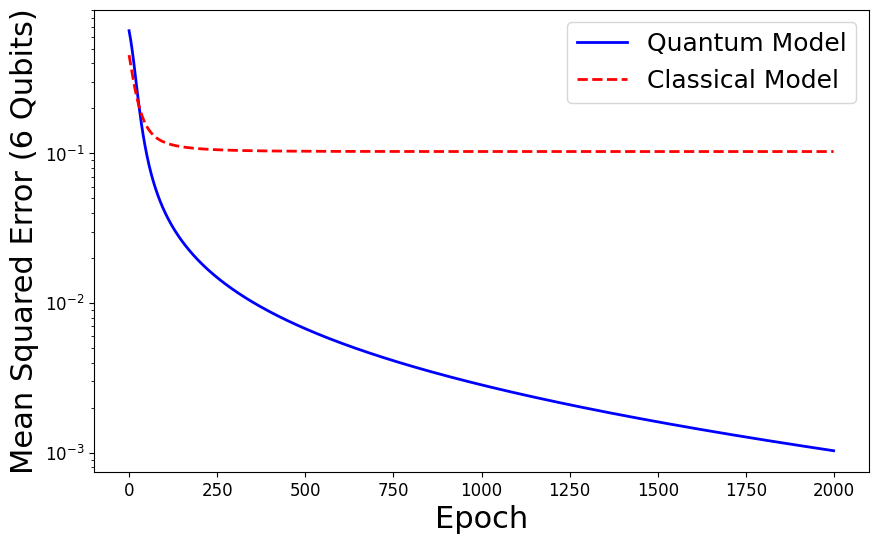

In [18]:
plot(history_q, history_c, n)